In [26]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from adjustText import adjust_text

df = pd.read_csv('all_data.csv')

# Parse model size (e.g., "4.9M" -> 4.9e6, "8.0B" -> 8.0e9)
def parse_model_size(size_str):
    if pd.isna(size_str):
        return np.nan
    size_str = str(size_str).strip()
    if size_str.endswith('B'):
        return float(size_str[:-1]) * 1e9
    elif size_str.endswith('M'):
        return float(size_str[:-1]) * 1e6
    elif size_str.endswith('K'):
        return float(size_str[:-1]) * 1e3
    else:
        return float(size_str)

df['model_size_num'] = df['model size'].apply(parse_model_size)

# Compute derived metrics using baseline models per task
def compute_metrics(df):
    baselines = df[df['baseline?'] == True][['task', 'performance', 'CO2']].copy()
    baselines.columns = ['task', 'perf_baseline', 'co2_baseline']
    df = df.merge(baselines, on='task', how='left')
    
    df['delta performance'] = np.where(
        df['baseline?'] == True, np.nan,
        (df['performance'] - df['perf_baseline']) / df['perf_baseline']
    )
    df['CO2 ratio'] = np.where(
        df['baseline?'] == True, np.nan,
        df['CO2'] / df['co2_baseline']
    )
    df['log delta CO2'] = np.where(
        df['baseline?'] == True, np.nan,
        np.log10(df['CO2'] / df['co2_baseline'])
    )
    df['ICER'] = np.where(
        (df['baseline?'] == True) | (df['delta performance'] == 0),
        np.nan,
        df['log delta CO2'] / df['delta performance']
    )
    df = df.drop(columns=['perf_baseline', 'co2_baseline'])
    return df

def classify_quadrant(row):
    dp, co2_ratio = row['delta performance'], row['CO2 ratio']
    if pd.isna(dp) or pd.isna(co2_ratio):
        return None
    if co2_ratio <= 1 and dp > 0:
        return 'Dominant'
    elif co2_ratio > 1 and dp > 0:
        return 'Tradeoff'
    elif co2_ratio > 1 and dp <= 0:
        return 'Dominated'
    else:
        return 'Inverse'

df = compute_metrics(df)
df['quadrant'] = df.apply(classify_quadrant, axis=1)

# Task order and colors
tasks = ['MatGen', 'MolGen', 'Retro', 'Forward', 'MolOpt', 'MDSim']
task_color_map = {
    'MatGen': 'tab:green', 'MolGen': 'tab:cyan', 'Retro': 'tab:blue',
    'Forward': 'tab:orange', 'MolOpt': 'tab:red', 'MDSim': 'tab:purple'
}

# Performance metric names per task
perf_metric_names = {
    'MatGen': 'SUN',
    'MolGen': 'VUN',
    'Retro': 'Top-50 Accuracy',
    'Forward': 'Top-3 Accuracy',
    'MolOpt': 'CPS',
    'MDSim': 'MSD'
}

marker_map = {
    'MLP': 'o', 'GNN': 'd', 'Transformer': '^',
    'Diffusion': 'X', 'Difussion': 'X', 'LLM': '*'
}
quad_bg = {'Dominant': '#c8e6c9', 'Tradeoff': '#fff9c4', 'Dominated': '#ffcdd2', 'Inverse': '#e0e0e0'}

# Size scaling function (log scale for model size)
def get_marker_size(model_size, min_size=20, max_size=500):
    if pd.isna(model_size):
        return 100
    log_size = np.log10(model_size)
    log_min, log_max = 5, 10  # 100K to 10B
    normalized = (log_size - log_min) / (log_max - log_min)
    normalized = np.clip(normalized, 0, 1)
    return min_size + normalized * (max_size - min_size)

df['marker_size'] = df['model_size_num'].apply(get_marker_size)

df_valid = df.dropna(subset=['quadrant'])

print(f"Total models: {len(df)}, Models with quadrant data: {len(df_valid)}")
print(f"Tasks: {tasks}")
print(f"Model size range: {df['model_size_num'].min():.2e} - {df['model_size_num'].max():.2e}")

Total models: 46, Models with quadrant data: 40
Tasks: ['MatGen', 'MolGen', 'Retro', 'Forward', 'MolOpt', 'MDSim']
Model size range: 4.13e+05 - 8.00e+09


## Figure 1: Year vs Performance (Raw Data)

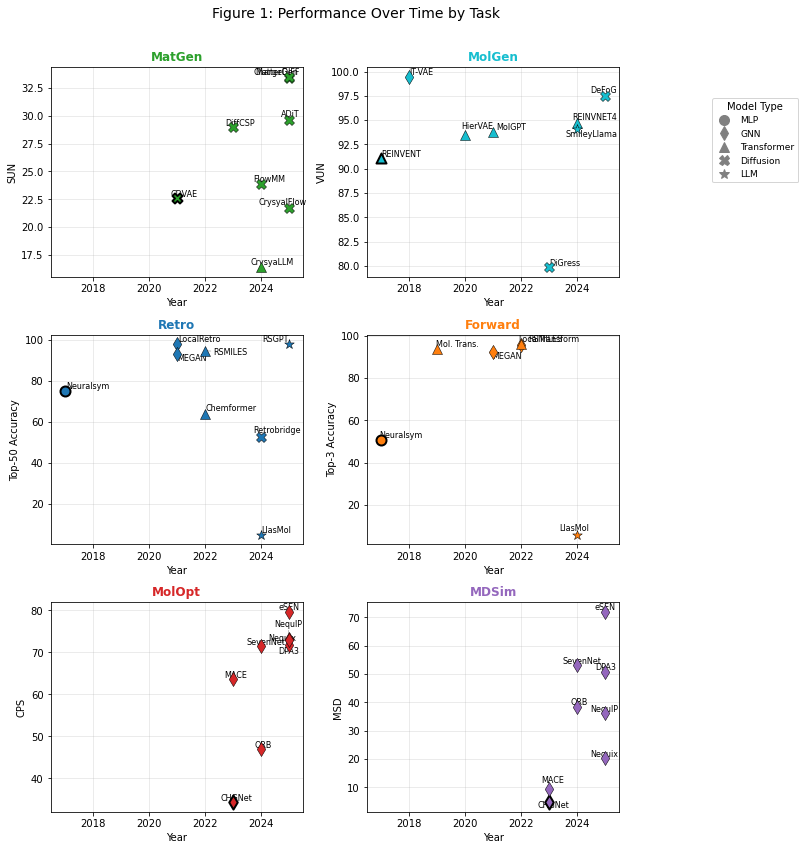

In [27]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
axes = axes.flatten()

# Global x-axis limits (years)
year_min, year_max = df['year'].min() - 0.5, df['year'].max() + 0.5

for idx, task in enumerate(tasks):
    ax = axes[idx]
    task_data = df[df['task'] == task].sort_values('year')
    
    texts = []
    for _, row in task_data.iterrows():
        marker = marker_map.get(row['model type'], 'o')
        edge_width = 2 if row['baseline?'] == True else 0.5
        
        ax.scatter(row['year'], row['performance'], 
                   color=task_color_map[task], marker=marker, s=100,
                   edgecolors='black', linewidths=edge_width, zorder=5)
        texts.append(ax.text(row['year'], row['performance'], row['model'], fontsize=8))
    
    if texts:
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
    
    ax.set_xlim(year_min, year_max)
    ax.set_title(task, fontsize=12, fontweight='bold', color=task_color_map[task])
    ax.set_xlabel('Year')
    ax.set_ylabel(perf_metric_names[task])
    ax.grid(True, alpha=0.3)

# Shared legend outside
model_legend = [Line2D([0], [0], marker=marker_map[m], color='gray',
                       linestyle='None', label=m, markersize=10)
                for m in ['MLP', 'GNN', 'Transformer', 'Diffusion', 'LLM']]

fig.legend(handles=model_legend, title='Model Type', loc='upper right', 
           bbox_to_anchor=(1.12, 0.88), fontsize=9)

fig.suptitle('Figure 1: Performance Over Time by Task', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.88, 0.97])
plt.savefig('figure1_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 2: Year vs Model Size

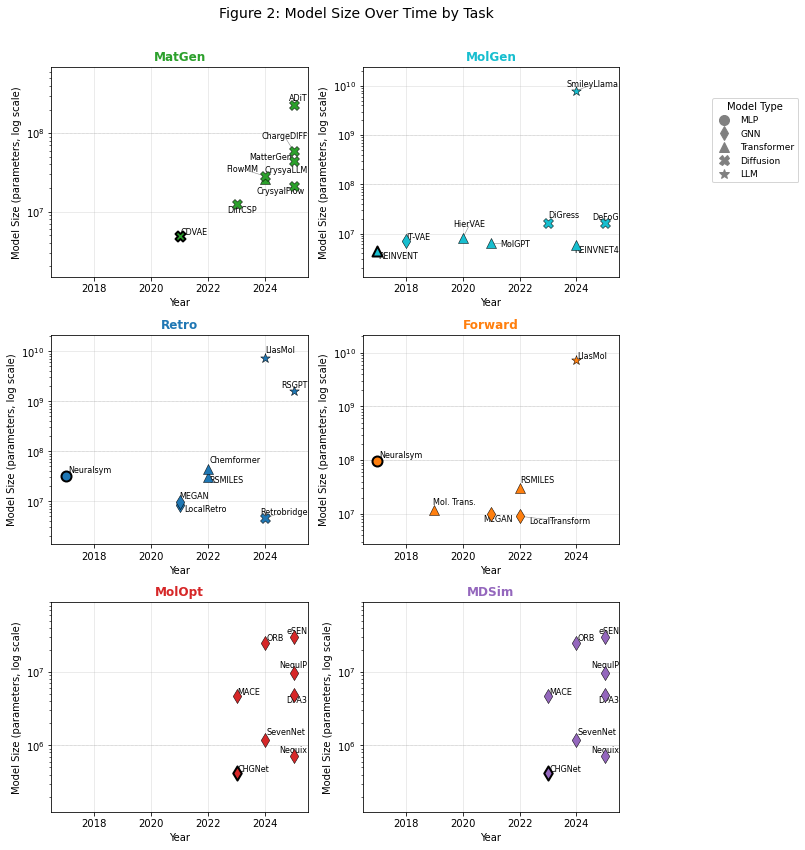

In [28]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
axes = axes.flatten()

# Global x-axis limits (years) - same as Figure 1
year_min, year_max = df['year'].min() - 0.5, df['year'].max() + 0.5

for idx, task in enumerate(tasks):
    ax = axes[idx]
    task_data = df[df['task'] == task].sort_values('year')

    texts = []
    for _, row in task_data.iterrows():
        marker = marker_map.get(row['model type'], 'o')
        edge_width = 2 if row['baseline?'] == True else 0.5

        ax.scatter(row['year'], row['model_size_num'],
                   color=task_color_map[task], marker=marker, s=100,
                   edgecolors='black', linewidths=edge_width, zorder=5)
        texts.append(ax.text(row['year'], row['model_size_num'], row['model'], fontsize=8))

    ax.set_xlim(year_min, year_max)
    ax.set_yscale('log')
    
    # Set y limits
    y_vals = task_data['model_size_num'].values
    y_min, y_max = y_vals.min() * 0.3, y_vals.max() * 3
    ax.set_ylim(y_min, y_max)
    
    if texts:
        adjust_text(texts, ax=ax, 
                    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
                    expand_points=(1.2, 1.2), expand_text=(1.1, 1.1),
                    force_text=(0.5, 0.5), force_points=(0.5, 0.5),
                    lim=100)
    
    ax.set_title(task, fontsize=12, fontweight='bold', color=task_color_map[task])
    ax.set_xlabel('Year')
    ax.set_ylabel('Model Size (parameters, log scale)')
    ax.grid(True, alpha=0.3)
    
    # Add horizontal reference lines for common sizes
    for size, label in [(1e6, '1M'), (1e8, '100M'), (1e9, '1B')]:
        if y_min < size < y_max:
            ax.axhline(y=size, color='gray', linestyle=':', alpha=0.5, linewidth=0.5)

# Shared legend outside the subplots
model_legend = [Line2D([0], [0], marker=marker_map[m], color='gray',
                       linestyle='None', label=m, markersize=10)
                for m in ['MLP', 'GNN', 'Transformer', 'Diffusion', 'LLM']]

fig.legend(handles=model_legend, title='Model Type', loc='upper right',
           bbox_to_anchor=(1.12, 0.88), fontsize=9)

fig.suptitle('Figure 2: Model Size Over Time by Task', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.88, 0.97])
plt.savefig('figure2_model_size.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 2b: Year vs Carbon Cost (Log Scale)

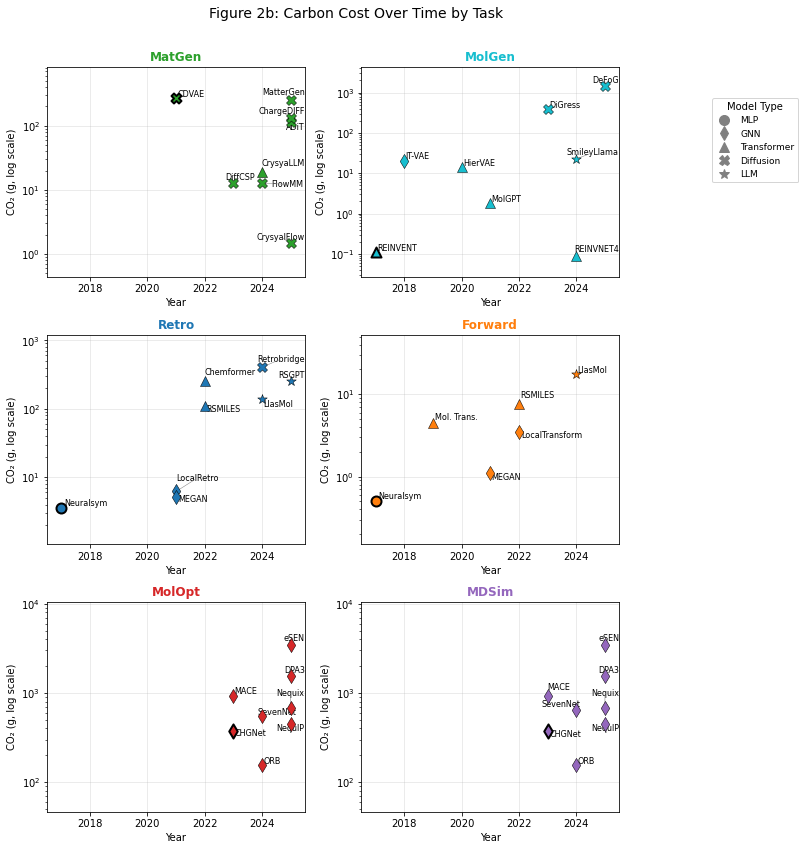

In [29]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
axes = axes.flatten()

# Global x-axis limits (years) - same as Figure 1
year_min, year_max = df['year'].min() - 0.5, df['year'].max() + 0.5

for idx, task in enumerate(tasks):
    ax = axes[idx]
    task_data = df[df['task'] == task].sort_values('year')

    texts = []
    for _, row in task_data.iterrows():
        marker = marker_map.get(row['model type'], 'o')
        edge_width = 2 if row['baseline?'] == True else 0.5

        ax.scatter(row['year'], row['CO2'],
                   color=task_color_map[task], marker=marker, s=100,
                   edgecolors='black', linewidths=edge_width, zorder=5)
        texts.append(ax.text(row['year'], row['CO2'], row['model'], fontsize=8))

    ax.set_xlim(year_min, year_max)
    ax.set_yscale('log')
    
    # Set y limits
    y_vals = task_data['CO2'].values
    y_min, y_max = y_vals.min() * 0.3, y_vals.max() * 3
    ax.set_ylim(y_min, y_max)
    
    if texts:
        adjust_text(texts, ax=ax, 
                    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
                    expand_points=(1.2, 1.2), expand_text=(1.1, 1.1),
                    force_text=(0.5, 0.5), force_points=(0.5, 0.5),
                    lim=100)
    
    ax.set_title(task, fontsize=12, fontweight='bold', color=task_color_map[task])
    ax.set_xlabel('Year')
    ax.set_ylabel('CO₂ (g, log scale)')
    ax.grid(True, alpha=0.3)

# Shared legend outside the subplots
model_legend = [Line2D([0], [0], marker=marker_map[m], color='gray',
                       linestyle='None', label=m, markersize=10)
                for m in ['MLP', 'GNN', 'Transformer', 'Diffusion', 'LLM']]

fig.legend(handles=model_legend, title='Model Type', loc='upper right',
           bbox_to_anchor=(1.12, 0.88), fontsize=9)

fig.suptitle('Figure 2b: Carbon Cost Over Time by Task', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.88, 0.97])
plt.savefig('figure2b_carbon.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 3: Quadrant Analysis with Trajectory (Main Figure)

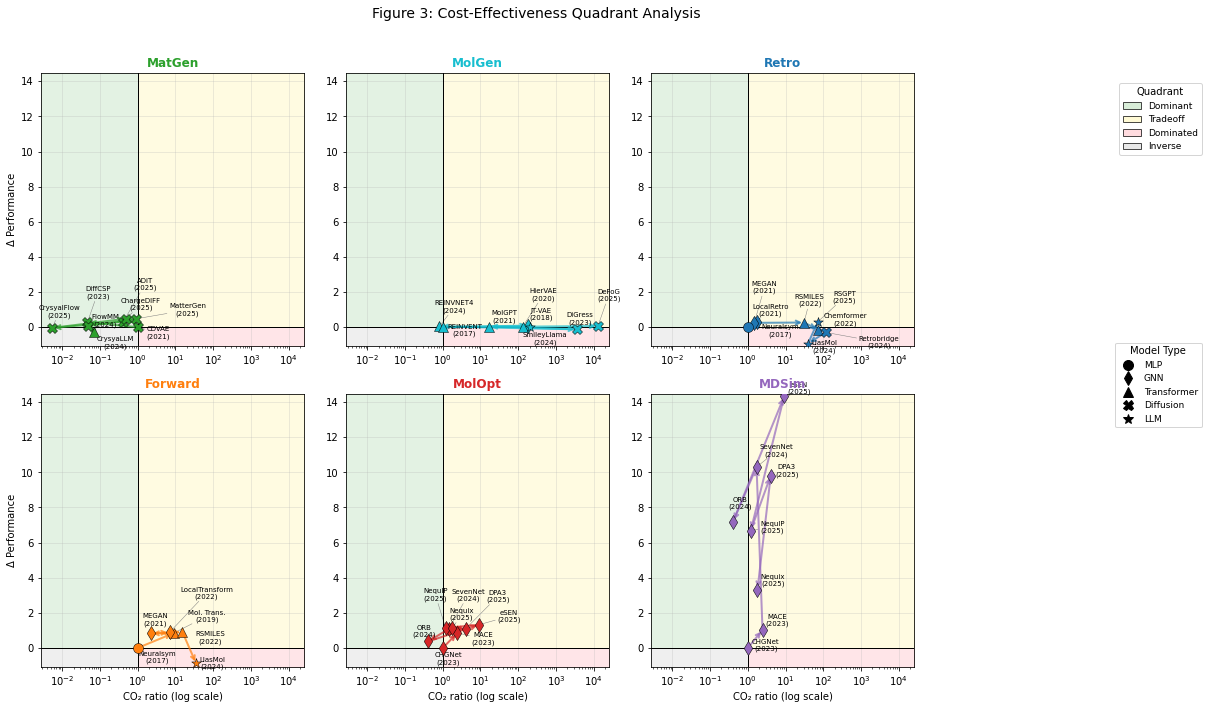

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Use global limits across ALL tasks for comparison
# x = CO2 ratio (log scale), y = delta performance
x_data = df_valid['CO2 ratio']
y_data = df_valid['delta performance']
x_min, x_max = x_data.min() * 0.5, x_data.max() * 2
y_min, y_max = y_data.min() - 0.15, y_data.max() + 0.15

# Get baseline models for each task (include year)
baselines = df[df['baseline?'] == True][['task', 'model', 'model type', 'year']].set_index('task')

for idx, task in enumerate(tasks):
    ax = axes[idx]
    task_data = df_valid[df_valid['task'] == task].sort_values('year')
    baseline_model = baselines.loc[task, 'model'] if task in baselines.index else 'Baseline'
    baseline_marker = marker_map.get(baselines.loc[task, 'model type'], 'o') if task in baselines.index else 'o'
    baseline_year = int(baselines.loc[task, 'year']) if task in baselines.index else ''
    
    ax.set_xscale('log')
    
    # Quadrant shading (log scale: boundary at x=1)
    ax.fill_between([x_min, 1], y_max, 0, color=quad_bg['Dominant'], alpha=0.5)  # top-left
    ax.fill_between([1, x_max], y_max, 0, color=quad_bg['Tradeoff'], alpha=0.5)  # top-right
    ax.fill_between([1, x_max], 0, y_min, color=quad_bg['Dominated'], alpha=0.5)  # bottom-right
    ax.fill_between([x_min, 1], 0, y_min, color=quad_bg['Inverse'], alpha=0.5)  # bottom-left
    
    # Plot baseline at (1, 0)
    ax.scatter(1, 0, color=task_color_map[task], marker=baseline_marker, s=100,
               edgecolors='black', linewidths=0.5, zorder=6)
    
    # Draw arrow from baseline to first model
    if len(task_data) >= 1:
        first_row = task_data.iloc[0]
        ax.annotate('', xy=(first_row['CO2 ratio'], first_row['delta performance']),
                    xytext=(1, 0),
                    arrowprops=dict(arrowstyle='->', color=task_color_map[task], lw=2, alpha=0.7))
    
    # Draw trajectory arrows between subsequent models
    if len(task_data) >= 2:
        for i in range(len(task_data) - 1):
            row1, row2 = task_data.iloc[i], task_data.iloc[i + 1]
            ax.annotate('', xy=(row2['CO2 ratio'], row2['delta performance']),
                        xytext=(row1['CO2 ratio'], row1['delta performance']),
                        arrowprops=dict(arrowstyle='->', color=task_color_map[task], lw=2, alpha=0.7))
    
    # Plot points with labels (show year for baseline too)
    texts = [ax.text(1, 0, f"{baseline_model}\n({baseline_year})", fontsize=7)]
    for _, row in task_data.iterrows():
        marker = marker_map.get(row['model type'], 'o')
        ax.scatter(row['CO2 ratio'], row['delta performance'], 
                   color=task_color_map[task], marker=marker, s=100,
                   edgecolors='black', linewidths=0.5, zorder=5)
        texts.append(ax.text(row['CO2 ratio'], row['delta performance'],
                             f"{row['model']}\n({int(row['year'])})", fontsize=7))
    
    if texts:
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
    
    # Quadrant boundaries
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax.axvline(x=1, color='black', linestyle='-', linewidth=1)
    
    # Same limits for all subplots
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(task, fontsize=12, fontweight='bold', color=task_color_map[task])
    ax.grid(True, alpha=0.3)
    
    if idx >= 3:
        ax.set_xlabel('CO₂ ratio (log scale)')
    if idx % 3 == 0:
        ax.set_ylabel('Δ Performance')

# Shared legends outside
quad_legend = [Patch(facecolor=quad_bg[q], label=q, alpha=0.7, edgecolor='black')
               for q in ['Dominant', 'Tradeoff', 'Dominated', 'Inverse']]
model_legend = [Line2D([0], [0], marker=marker_map[m], color='black',
                       linestyle='None', label=m, markersize=10)
                for m in ['MLP', 'GNN', 'Transformer', 'Diffusion', 'LLM']]

fig.legend(handles=quad_legend, title='Quadrant', loc='upper right', 
           bbox_to_anchor=(1.12, 0.88), fontsize=9)
fig.legend(handles=model_legend, title='Model Type', loc='upper right', 
           bbox_to_anchor=(1.12, 0.52), fontsize=9)

fig.suptitle('Figure 3: Cost-Effectiveness Quadrant Analysis', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.86, 0.96])
plt.savefig('figure3_quadrant.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 3b: Quadrant Analysis with Independent Scales
Each task uses its own x/y limits to better visualize arrows and trajectories within each field.

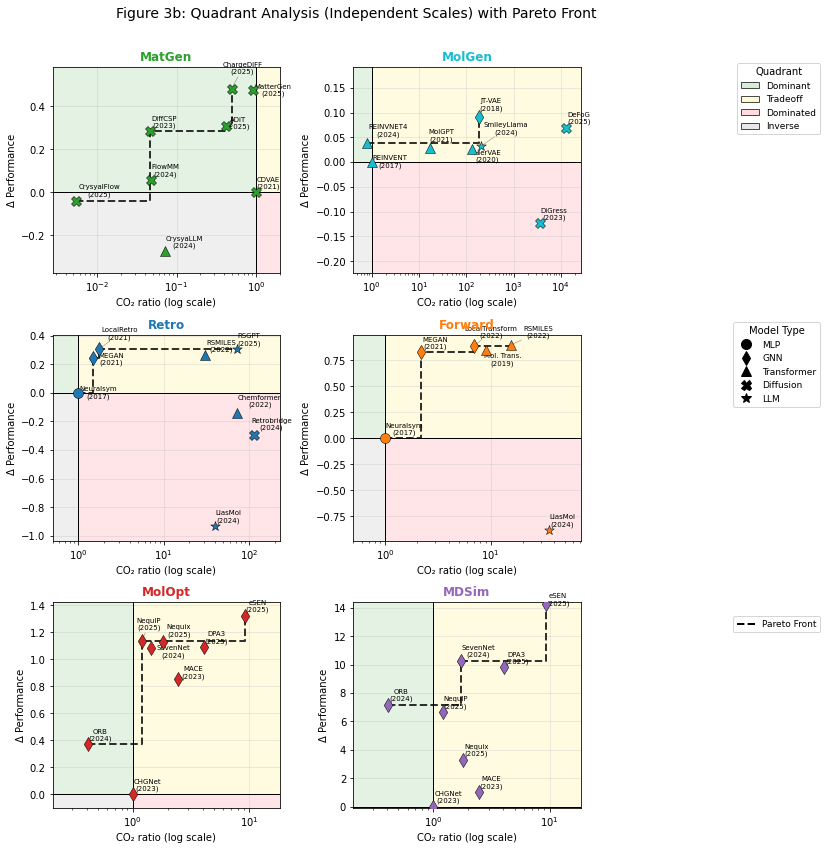

In [31]:
def get_pareto_front(points):
    """
    Find Pareto-optimal points where we want to minimize x (CO2 ratio) and maximize y (performance).
    Returns indices of Pareto-optimal points sorted by x.
    """
    if len(points) == 0:
        return []
    
    # Include baseline at (1, 0)
    points_with_baseline = np.vstack([[1, 0], points])
    
    pareto_indices = []
    for i, (x_i, y_i) in enumerate(points_with_baseline):
        is_pareto = True
        for j, (x_j, y_j) in enumerate(points_with_baseline):
            if i != j:
                # Point j dominates point i if j has lower x AND higher y
                if x_j <= x_i and y_j >= y_i and (x_j < x_i or y_j > y_i):
                    is_pareto = False
                    break
        if is_pareto:
            pareto_indices.append(i)
    
    # Get Pareto points and sort by x
    pareto_points = points_with_baseline[pareto_indices]
    sorted_idx = np.argsort(pareto_points[:, 0])
    return pareto_points[sorted_idx]

fig, axes = plt.subplots(3, 2, figsize=(10, 12))
axes = axes.flatten()

# Get baseline models for each task (include year)
baselines = df[df['baseline?'] == True][['task', 'model', 'model type', 'year']].set_index('task')

for idx, task in enumerate(tasks):
    ax = axes[idx]
    task_data = df_valid[df_valid['task'] == task].sort_values('year')
    baseline_model = baselines.loc[task, 'model'] if task in baselines.index else 'Baseline'
    baseline_marker = marker_map.get(baselines.loc[task, 'model type'], 'o') if task in baselines.index else 'o'
    baseline_year = int(baselines.loc[task, 'year']) if task in baselines.index else ''
    
    ax.set_xscale('log')
    
    if len(task_data) == 0:
        x_min, x_max = 0.1, 10
        y_min, y_max = -0.2, 0.2
    else:
        x_data = task_data['CO2 ratio']
        y_data = task_data['delta performance']
        x_min, x_max = x_data.min() * 0.5, x_data.max() * 2
        y_min, y_max = y_data.min() - 0.1, y_data.max() + 0.1
    
    # Ensure baseline (1, 0) is visible
    x_min, x_max = min(x_min, 0.5), max(x_max, 2)
    y_min, y_max = min(y_min, -0.1), max(y_max, 0.1)
    
    # Quadrant shading (log scale: boundary at x=1)
    ax.fill_between([x_min, 1], y_max, 0, color=quad_bg['Dominant'], alpha=0.5)
    ax.fill_between([1, x_max], y_max, 0, color=quad_bg['Tradeoff'], alpha=0.5)
    ax.fill_between([1, x_max], 0, y_min, color=quad_bg['Dominated'], alpha=0.5)
    ax.fill_between([x_min, 1], 0, y_min, color=quad_bg['Inverse'], alpha=0.5)
    
    # Plot baseline at (1, 0)
    ax.scatter(1, 0, color=task_color_map[task], marker=baseline_marker, s=100,
               edgecolors='black', linewidths=0.5, zorder=6)
    
    # # Draw arrow from baseline to first model
    # if len(task_data) >= 1:
    #     first_row = task_data.iloc[0]
    #     ax.annotate('', xy=(first_row['CO2 ratio'], first_row['delta performance']),
    #                 xytext=(1, 0),
    #                 arrowprops=dict(arrowstyle='->', color=task_color_map[task], lw=2, alpha=0.7))
    
    # # Draw trajectory arrows between subsequent models
    # if len(task_data) >= 2:
    #     for i in range(len(task_data) - 1):
    #         row1, row2 = task_data.iloc[i], task_data.iloc[i + 1]
    #         ax.annotate('', xy=(row2['CO2 ratio'], row2['delta performance']),
    #                     xytext=(row1['CO2 ratio'], row1['delta performance']),
    #                     arrowprops=dict(arrowstyle='->', color=task_color_map[task], lw=2, alpha=0.7))
    
    # Compute and draw Pareto front
    if len(task_data) > 0:
        points = task_data[['CO2 ratio', 'delta performance']].values
        pareto_points = get_pareto_front(points)
        if len(pareto_points) > 1:
            # Draw step-wise Pareto front line
            ax.step(pareto_points[:, 0], pareto_points[:, 1], where='post',
                    color='black', linestyle='--', linewidth=2, alpha=0.8, zorder=4)
    
    # Plot points with labels (show year for baseline too)
    texts = [ax.text(1, 0, f"{baseline_model}\n({baseline_year})", fontsize=7)]
    for _, row in task_data.iterrows():
        marker = marker_map.get(row['model type'], 'o')
        ax.scatter(row['CO2 ratio'], row['delta performance'], 
                   color=task_color_map[task], marker=marker, s=100,
                   edgecolors='black', linewidths=0.5, zorder=5)
        texts.append(ax.text(row['CO2 ratio'], row['delta performance'],
                             f"{row['model']}\n({int(row['year'])})", fontsize=7))
    
    if texts:
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
    
    # Quadrant boundaries
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax.axvline(x=1, color='black', linestyle='-', linewidth=1)
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(task, fontsize=12, fontweight='bold', color=task_color_map[task])
    ax.set_xlabel('CO₂ ratio (log scale)')
    ax.set_ylabel('Δ Performance')
    ax.grid(True, alpha=0.3)

# Shared legends outside
quad_legend = [Patch(facecolor=quad_bg[q], label=q, alpha=0.7, edgecolor='black')
               for q in ['Dominant', 'Tradeoff', 'Dominated', 'Inverse']]
model_legend = [Line2D([0], [0], marker=marker_map[m], color='black',
                       linestyle='None', label=m, markersize=10)
                for m in ['MLP', 'GNN', 'Transformer', 'Diffusion', 'LLM']]
pareto_legend = [Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Pareto Front')]

fig.legend(handles=quad_legend, title='Quadrant', loc='upper right', 
           bbox_to_anchor=(1.15, 0.92), fontsize=9)
fig.legend(handles=model_legend, title='Model Type', loc='upper right', 
           bbox_to_anchor=(1.15, 0.62), fontsize=9)
fig.legend(handles=pareto_legend, loc='upper right',
           bbox_to_anchor=(1.15, 0.28), fontsize=9)

fig.suptitle('Figure 3b: Quadrant Analysis (Independent Scales) with Pareto Front', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.84, 0.97])
plt.savefig('figure3b_quadrant_independent.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 4: All Models Overview (No Arrows/Labels)

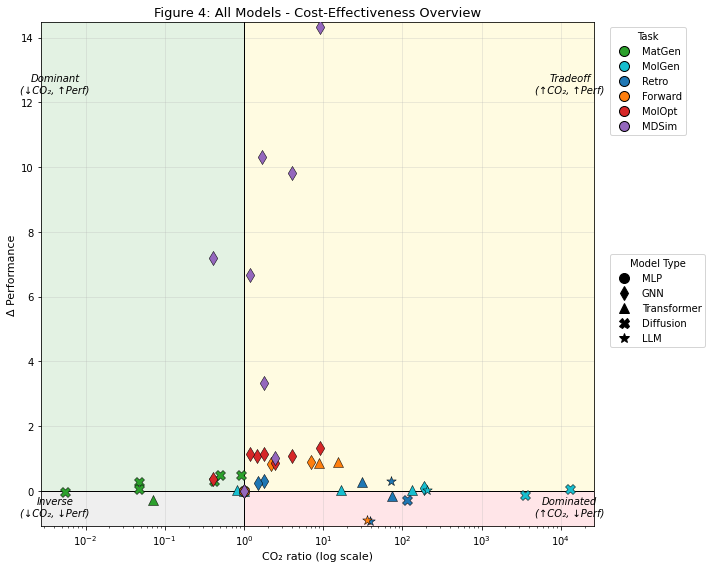

In [32]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.set_xscale('log')

# Get axis limits
x_data = df_valid['CO2 ratio']
y_data = df_valid['delta performance']
x_min, x_max = x_data.min() * 0.5, x_data.max() * 2
y_min, y_max = y_data.min() - 0.15, y_data.max() + 0.15

# Quadrant shading (log scale: boundary at x=1)
ax.fill_between([x_min, 1], y_max, 0, color=quad_bg['Dominant'], alpha=0.5)
ax.fill_between([1, x_max], y_max, 0, color=quad_bg['Tradeoff'], alpha=0.5)
ax.fill_between([1, x_max], 0, y_min, color=quad_bg['Dominated'], alpha=0.5)
ax.fill_between([x_min, 1], 0, y_min, color=quad_bg['Inverse'], alpha=0.5)

# Plot all baselines at (1, 0)
baselines = df[df['baseline?'] == True][['task', 'model', 'model type']].set_index('task')
for task in tasks:
    if task in baselines.index:
        baseline_marker = marker_map.get(baselines.loc[task, 'model type'], 'o')
        ax.scatter(1, 0, color=task_color_map[task], marker=baseline_marker, s=100,
                   edgecolors='black', linewidths=0.5, zorder=6)

# Plot all models (no arrows, no labels)
for _, row in df_valid.iterrows():
    color = task_color_map.get(row['task'], 'gray')
    marker = marker_map.get(row['model type'], 'o')
    ax.scatter(row['CO2 ratio'], row['delta performance'], 
               color=color, marker=marker, s=100,
               edgecolors='black', linewidths=0.5, zorder=5)

# Quadrant boundaries
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.axvline(x=1, color='black', linestyle='-', linewidth=1)

# Quadrant labels
ax.text(x_min * 1.5, y_max * 0.85, 'Dominant\n(↓CO₂, ↑Perf)', ha='center', fontsize=10, style='italic')
ax.text(x_max * 0.5, y_max * 0.85, 'Tradeoff\n(↑CO₂, ↑Perf)', ha='center', fontsize=10, style='italic')
ax.text(x_max * 0.5, y_min * 0.7, 'Dominated\n(↑CO₂, ↓Perf)', ha='center', fontsize=10, style='italic')
ax.text(x_min * 1.5, y_min * 0.7, 'Inverse\n(↓CO₂, ↓Perf)', ha='center', fontsize=10, style='italic')

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel('CO₂ ratio (log scale)', fontsize=11)
ax.set_ylabel('Δ Performance', fontsize=11)
ax.set_title('Figure 4: All Models - Cost-Effectiveness Overview', fontsize=13)
ax.grid(True, alpha=0.3)

# Legends
task_legend = [Line2D([0], [0], marker='o', color='w', markerfacecolor=task_color_map[t],
                      label=t, markersize=10, markeredgecolor='black')
               for t in tasks]
model_legend = [Line2D([0], [0], marker=marker_map[m], color='black',
                       linestyle='None', label=m, markersize=10)
                for m in ['MLP', 'GNN', 'Transformer', 'Diffusion', 'LLM']]

leg1 = ax.legend(handles=task_legend, title='Task', loc='upper left', bbox_to_anchor=(1.02, 1))
ax.add_artist(leg1)
ax.legend(handles=model_legend, title='Model Type', loc='upper left', bbox_to_anchor=(1.02, 0.55))

plt.tight_layout()
plt.savefig('figure4_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 5: Model Size vs Carbon Emission

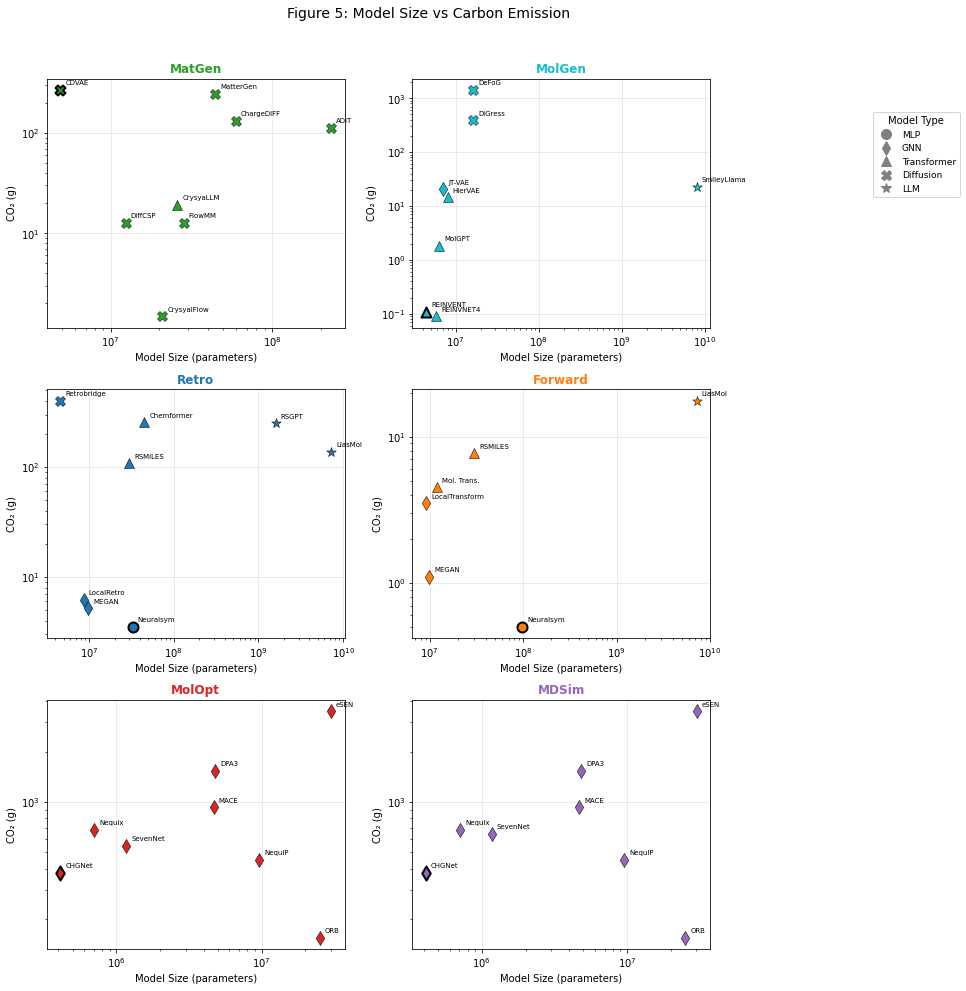

In [33]:
fig, axes = plt.subplots(3, 2, figsize=(12, 14))
axes = axes.flatten()

for idx, task in enumerate(tasks):
    ax = axes[idx]
    task_data = df[df['task'] == task].dropna(subset=['model_size_num', 'CO2'])
    
    # Plot data points
    for _, row in task_data.iterrows():
        marker = marker_map.get(row['model type'], 'o')
        edge_width = 2 if row['baseline?'] == True else 0.5
        ax.scatter(row['model_size_num'], row['CO2'],
                   color=task_color_map[task], marker=marker, s=100,
                   edgecolors='black', linewidths=edge_width, zorder=5)
        ax.annotate(row['model'], (row['model_size_num'], row['CO2']),
                    xytext=(5, 5), textcoords='offset points', fontsize=7)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(task, fontsize=12, fontweight='bold', color=task_color_map[task])
    ax.set_xlabel('Model Size (parameters)')
    ax.set_ylabel('CO₂ (g)')
    ax.grid(True, alpha=0.3)

# Shared legend for markers
model_legend = [Line2D([0], [0], marker=marker_map[m], color='gray',
                       linestyle='None', label=m, markersize=10)
                for m in ['MLP', 'GNN', 'Transformer', 'Diffusion', 'LLM']]

fig.legend(handles=model_legend, title='Model Type', 
           loc='upper right', bbox_to_anchor=(1.12, 0.88), fontsize=9)

fig.suptitle('Figure 5: Model Size vs Carbon Emission', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.88, 0.96])
plt.savefig('figure5_size_vs_co2.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 6: Carbon Emission Extrapolation to 2030

/var/folders/5j/tj9pc4dx5d52nzmbm3h0mnxh0000gn/T/ipykernel_4771/783744244.py:19: RuntimeWarning: divide by zero encountered in true_divide
  median_slope = np.median(np.diff(log_co2) / np.diff(years)) if len(years) > 1 else 0


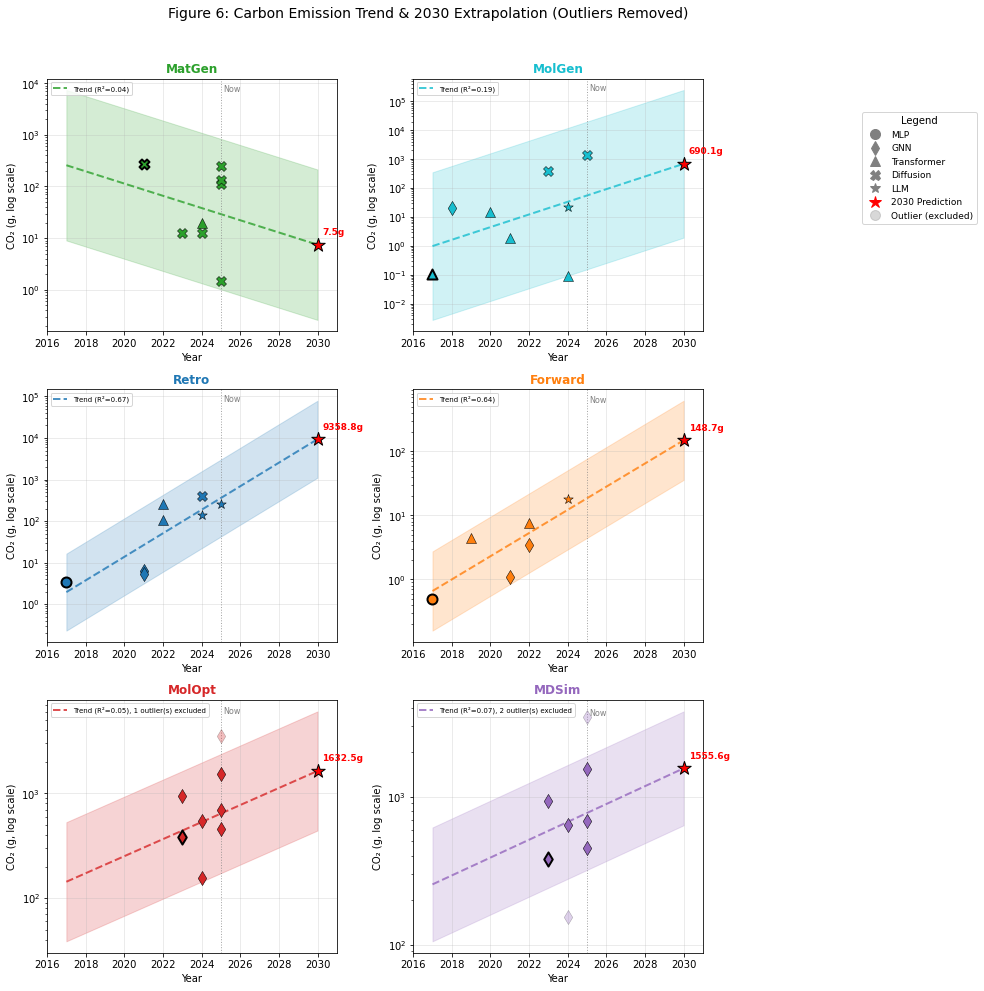


2030 Carbon Emission Predictions by Task (Robust Fitting)
Task         Trend        R²       Outliers   Prediction   95% CI              
---------------------------------------------------------------------------
MatGen       decreasing   0.044    0               7.5 g    [0.3 - 213.5]
MolGen       increasing   0.186    0             690.1 g    [1.9 - 245675.9]
Retro        increasing   0.673    0            9358.8 g    [1108.3 - 79027.4]
Forward      increasing   0.638    0             148.7 g    [35.8 - 617.7]
MolOpt       increasing   0.054    1            1632.5 g    [441.2 - 6040.8]
MDSim        increasing   0.073    2            1555.6 g    [641.2 - 3774.1]

Note: Outliers identified using IQR (threshold=1.0) + z-score (>2.5) methods.
Predictions should be interpreted with caution due to limited data points.


In [34]:
from scipy import stats

fig, axes = plt.subplots(3, 2, figsize=(12, 14))
axes = axes.flatten()

# Years for extrapolation
future_years = np.arange(2017, 2031)
target_year = 2030

# Store predictions for summary
predictions = {}

def remove_outliers_iqr(years, log_co2, threshold=1.0):
    """Remove outliers using IQR method on residuals from median trend."""
    if len(years) < 4:
        return years, log_co2, np.ones(len(years), dtype=bool)
    
    # Fit initial trend using median
    median_slope = np.median(np.diff(log_co2) / np.diff(years)) if len(years) > 1 else 0
    median_intercept = np.median(log_co2 - median_slope * years)
    
    # Calculate residuals
    residuals = log_co2 - (median_slope * years + median_intercept)
    
    # IQR method with tighter threshold
    q1, q3 = np.percentile(residuals, [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - threshold * iqr
    upper_bound = q3 + threshold * iqr
    
    # Also check for extreme values using z-score as secondary filter
    z_scores = np.abs((log_co2 - np.median(log_co2)) / (np.std(log_co2) + 1e-10))
    z_mask = z_scores < 2.5  # Flag points with z-score > 2.5
    
    iqr_mask = (residuals >= lower_bound) & (residuals <= upper_bound)
    mask = iqr_mask & z_mask  # Must pass both filters
    
    return years[mask], log_co2[mask], mask

for idx, task in enumerate(tasks):
    ax = axes[idx]
    task_data = df[df['task'] == task].sort_values('year')
    
    years = task_data['year'].values
    co2_values = task_data['CO2'].values
    log_co2 = np.log10(co2_values)
    
    # Plot all historical data (outliers in lighter color)
    years_clean, log_co2_clean, mask = remove_outliers_iqr(years, log_co2)
    
    for i, (_, row) in enumerate(task_data.iterrows()):
        marker = marker_map.get(row['model type'], 'o')
        edge_width = 2 if row['baseline?'] == True else 0.5
        # Outliers shown with lower alpha
        alpha = 1.0 if mask[i] else 0.3
        ax.scatter(row['year'], row['CO2'],
                   color=task_color_map[task], marker=marker, s=100,
                   edgecolors='black', linewidths=edge_width, zorder=5, alpha=alpha)
    
    # Fit linear regression on cleaned log(CO2)
    if len(years_clean) >= 2:
        slope, intercept, r_value, p_value, std_err = stats.linregress(years_clean, log_co2_clean)
        
        # Generate trend line
        trend_log = slope * future_years + intercept
        trend_co2 = 10 ** trend_log
        
        # Confidence interval using cleaned residuals
        residuals = log_co2_clean - (slope * years_clean + intercept)
        residual_std = np.std(residuals) if len(residuals) > 1 else 0.5
        
        # Upper and lower bounds (±2 std for ~95% CI)
        upper_log = trend_log + 2 * residual_std
        lower_log = trend_log - 2 * residual_std
        upper_co2 = 10 ** upper_log
        lower_co2 = 10 ** lower_log
        
        # Plot trend line
        n_outliers = len(years) - len(years_clean)
        label = f'Trend (R²={r_value**2:.2f})'
        if n_outliers > 0:
            label += f', {n_outliers} outlier(s) excluded'
        ax.plot(future_years, trend_co2, '--', color=task_color_map[task], 
                linewidth=2, alpha=0.8, label=label)
        
        # Plot confidence band
        ax.fill_between(future_years, lower_co2, upper_co2, 
                        color=task_color_map[task], alpha=0.2)
        
        # Mark 2030 prediction
        pred_2030 = 10 ** (slope * 2030 + intercept)
        predictions[task] = {
            'prediction': pred_2030,
            'lower': 10 ** (slope * 2030 + intercept - 2 * residual_std),
            'upper': 10 ** (slope * 2030 + intercept + 2 * residual_std),
            'r_squared': r_value**2,
            'trend': 'increasing' if slope > 0 else 'decreasing',
            'n_outliers': n_outliers
        }
        
        ax.scatter(2030, pred_2030, color='red', marker='*', s=200, 
                   edgecolors='black', linewidths=1, zorder=10)
        ax.annotate(f'{pred_2030:.1f}g', (2030, pred_2030),
                    xytext=(5, 10), textcoords='offset points', fontsize=9,
                    fontweight='bold', color='red')
    
    # Vertical line at current year
    ax.axvline(x=2025, color='gray', linestyle=':', alpha=0.7, linewidth=1)
    ax.text(2025.1, ax.get_ylim()[1] * 0.9, 'Now', fontsize=8, color='gray')
    
    ax.set_yscale('log')
    ax.set_xlim(2016, 2031)
    ax.set_title(task, fontsize=12, fontweight='bold', color=task_color_map[task])
    ax.set_xlabel('Year')
    ax.set_ylabel('CO₂ (g, log scale)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=7)

# Shared legend for markers
model_legend = [Line2D([0], [0], marker=marker_map[m], color='gray',
                       linestyle='None', label=m, markersize=10)
                for m in ['MLP', 'GNN', 'Transformer', 'Diffusion', 'LLM']]
pred_legend = [Line2D([0], [0], marker='*', color='red', linestyle='None', 
                      label='2030 Prediction', markersize=12)]
outlier_legend = [Line2D([0], [0], marker='o', color='gray', linestyle='None',
                         label='Outlier (excluded)', markersize=10, alpha=0.3)]

fig.legend(handles=model_legend + pred_legend + outlier_legend, title='Legend', 
           loc='upper right', bbox_to_anchor=(1.14, 0.88), fontsize=9)

fig.suptitle('Figure 6: Carbon Emission Trend & 2030 Extrapolation (Outliers Removed)', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.86, 0.96])
plt.savefig('figure6_extrapolation.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print("\n" + "="*75)
print("2030 Carbon Emission Predictions by Task (Robust Fitting)")
print("="*75)
print(f"{'Task':<12} {'Trend':<12} {'R²':<8} {'Outliers':<10} {'Prediction':<12} {'95% CI':<20}")
print("-"*75)
for task, pred in predictions.items():
    print(f"{task:<12} {pred['trend']:<12} {pred['r_squared']:.3f}    {pred['n_outliers']:<10} {pred['prediction']:>8.1f} g    [{pred['lower']:.1f} - {pred['upper']:.1f}]")
print("="*75)
print("\nNote: Outliers identified using IQR (threshold=1.0) + z-score (>2.5) methods.")
print("Predictions should be interpreted with caution due to limited data points.")

## Figure 7: Carbon Cost Trend Over Time (All Tasks)

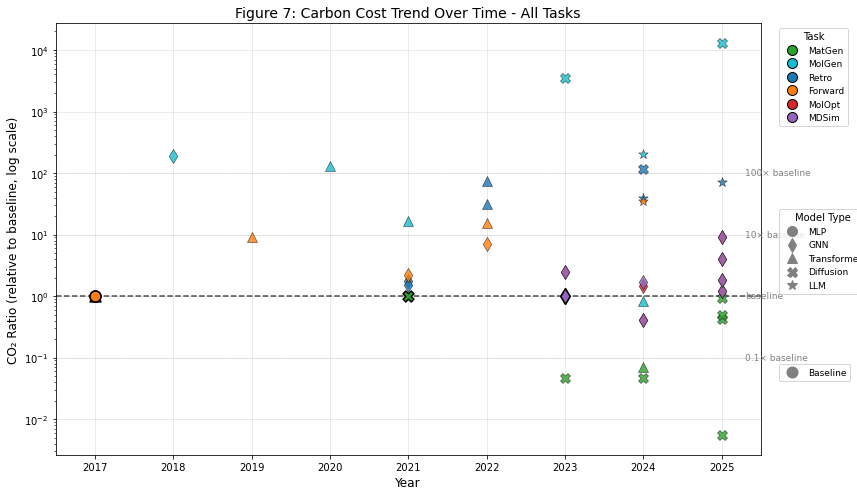


CO₂ Ratio Summary by Year:
2018: median=185.91x, mean=185.91x, n=1
2019: median=9.00x, mean=9.00x, n=1
2020: median=130.82x, mean=130.82x, n=1
2021: median=1.99x, mean=5.57x, n=4
2022: median=23.16x, mean=31.67x, n=4
2023: median=2.46x, mean=892.13x, n=4
2024: median=1.45x, mean=36.47x, n=11
2025: median=1.81x, mean=936.09x, n=14


In [35]:
fig, ax = plt.subplots(figsize=(12, 7))

# Plot baseline models at (year, 1) - CO2 ratio = 1 for baselines
baselines = df[df['baseline?'] == True]
for _, row in baselines.iterrows():
    marker = marker_map.get(row['model type'], 'o')
    ax.scatter(row['year'], 1, color=task_color_map[row['task']], marker=marker, s=120,
               edgecolors='black', linewidths=1.5, zorder=6, alpha=1.0)

# Plot all non-baseline models
for task in tasks:
    task_data = df_valid[df_valid['task'] == task].sort_values('year')
    
    for _, row in task_data.iterrows():
        marker = marker_map.get(row['model type'], 'o')
        ax.scatter(row['year'], row['CO2 ratio'],
                   color=task_color_map[task], marker=marker, s=100,
                   edgecolors='black', linewidths=0.5, zorder=5, alpha=0.8)

# Add baseline reference line at y=1
ax.axhline(y=1, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

# Set log scale for y-axis since ratios can vary widely
ax.set_yscale('log')

# Add horizontal reference lines
ax.axhline(y=10, color='gray', linestyle=':', linewidth=0.5, alpha=0.5)
ax.axhline(y=100, color='gray', linestyle=':', linewidth=0.5, alpha=0.5)
ax.axhline(y=0.1, color='gray', linestyle=':', linewidth=0.5, alpha=0.5)

# Labels and formatting
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('CO₂ Ratio (relative to baseline, log scale)', fontsize=12)
ax.set_title('Figure 7: Carbon Cost Trend Over Time - All Tasks', fontsize=14)
ax.set_xlim(2016.5, 2025.5)
ax.grid(True, alpha=0.3)

# Add text annotation for regions
ax.text(2025.3, 10, '10× baseline', fontsize=9, color='gray', va='center')
ax.text(2025.3, 100, '100× baseline', fontsize=9, color='gray', va='center')
ax.text(2025.3, 1, 'baseline', fontsize=9, color='gray', va='center')
ax.text(2025.3, 0.1, '0.1× baseline', fontsize=9, color='gray', va='center')

# Legends
task_legend = [Line2D([0], [0], marker='o', color='w', markerfacecolor=task_color_map[t],
                      label=t, markersize=10, markeredgecolor='black')
               for t in tasks]
model_legend = [Line2D([0], [0], marker=marker_map[m], color='gray',
                       linestyle='None', label=m, markersize=10)
                for m in ['MLP', 'GNN', 'Transformer', 'Diffusion', 'LLM']]
baseline_legend = [Line2D([0], [0], marker='o', color='gray', linestyle='None',
                          label='Baseline', markersize=10, markeredgewidth=2)]

leg1 = ax.legend(handles=task_legend, title='Task', loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)
ax.add_artist(leg1)
leg2 = ax.legend(handles=model_legend, title='Model Type', loc='upper left', bbox_to_anchor=(1.02, 0.58), fontsize=9)
ax.add_artist(leg2)
ax.legend(handles=baseline_legend, loc='upper left', bbox_to_anchor=(1.02, 0.22), fontsize=9)

plt.tight_layout()
plt.savefig('figure7_co2_ratio_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics by year
print("\nCO₂ Ratio Summary by Year:")
print("="*50)
for year in sorted(df_valid['year'].unique()):
    year_data = df_valid[df_valid['year'] == year]['CO2 ratio']
    print(f"{int(year)}: median={year_data.median():.2f}x, mean={year_data.mean():.2f}x, n={len(year_data)}")
print("="*50)